# Encabezado
Imports, funciones y carga de datos

In [1]:
# Imports
# Importo las Bibliotecas que voy a usar en el proyecto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# DataSources
df = pd.read_csv("data/delitos_2024.csv")

In [148]:
# Functions
# Definición de las funciones quevoy a usar en el proyecto.

def mostrar_valores_unicos(df, columnas):
    """
    Imprime en pantalla los valores únicos y sus frecuencias para 
    cada columna en 'columnas'
    """
    for col in columnas:
        print(f"\n{'='*50}")
        print(f"Columna: {col}")
        print(f"{'='*50}")

        conteo = df[col].value_counts(dropna=False)
        i=1
        for valor, cantidad in conteo.items():
            print(f"{[i]}\t{repr(valor)} -> {cantidad}")
            i+=1

def valores_unicos_a_df(df, columna):
    """
    Devuelve un DataFrame con los valores únicos y su frecuencia
    para una columna específica.
    """

    # reviso qe exista la columna, en caso de que me equivoque al escribirel nombre.
    if columna not in df.columns:
        raise ValueError(f"La columna '{columna}' no existe en el DataFrame")

    resultado = (
        df[columna]
        .value_counts(dropna=False)
        .reset_index()
    )
    resultado.columns = ['valor', 'cantidad']
    return resultado

def obtener_estacion(fecha):
    """
    Devuelve la estación del año en base a la fecha 'fecha'
    """
    mes = fecha.month
    dia = fecha.day

    if (mes == 12 and dia >= 21) or mes in [1, 2] or (mes == 3 and dia <= 20):
        return 'Verano'

    elif (mes == 3 and dia >= 21) or mes in [4, 5] or (mes == 6 and dia <= 20):
        return 'Otoño'

    elif (mes == 6 and dia >= 21) or mes in [7, 8] or (mes == 9 and dia <= 20):
        return 'Invierno'

    else:
        return 'Primavera'

# Exploración de datos (DEA)
Luego de haber cargado el dataset, hago una inspección geneal del dataframe buscando validar que sea útil para el TP.
```
Ejemplos
- df.head(), df.info(), df.describe()
- Detección de valores nulos (df.isnull().sum())
```

## Inspección rápida

In [4]:
df.shape # El DataFrame tiene que tener al menos 50K registros y 10 columnaspara este TP

(158838, 15)

In [5]:
# veo la estructura del DataFrame.
# con el datatype puedo completar el diccionario de datos que pide el TP
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 158838 entries, 0 to 158837
Data columns (total 15 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   id-mapa   158838 non-null  int64  
 1   anio      158838 non-null  int64  
 2   mes       158838 non-null  str    
 3   dia       158838 non-null  str    
 4   fecha     158838 non-null  str    
 5   franja    158791 non-null  float64
 6   tipo      158838 non-null  str    
 7   subtipo   158838 non-null  str    
 8   uso_arma  158838 non-null  str    
 9   uso_moto  158838 non-null  str    
 10  barrio    154916 non-null  str    
 11  comuna    154916 non-null  float64
 12  latitud   155004 non-null  float64
 13  longitud  155004 non-null  float64
 14  cantidad  158838 non-null  int64  
dtypes: float64(4), int64(3), str(8)
memory usage: 18.2 MB
None


In [6]:
df.head() # Sin argumentos, el método head() me trae los primeros 5 elementos del DataFrame

,id-mapa,anio,mes,dia,fecha,franja,tipo,subtipo,uso_arma,uso_moto,barrio,comuna,latitud,longitud,cantidad
0,1399612,2024,ENERO,LUNES,2024-01-01,17.0,Robo,Robo total,SI,NO,CHACARITA,15.0,-34.585182,-58.453967,1
1,1399613,2024,ENERO,LUNES,2024-01-01,6.0,Robo,Robo total,SI,NO,CHACARITA,15.0,-34.584186,-58.453476,1
2,1399614,2024,ENERO,LUNES,2024-01-01,1.0,Hurto,Hurto total,NO,NO,MATADEROS,9.0,-34.664360,-58.502121,1
3,1399615,2024,ENERO,LUNES,2024-01-01,19.0,Robo,Robo total,NO,NO,PALERMO,14.0,-34.564851,-58.434855,1
4,1399616,2024,ENERO,LUNES,2024-01-01,20.0,Hurto,Hurto total,NO,NO,SAN NICOLAS,1.0,-34.605522,-58.391176,1


In [7]:
# Obtengo una muestra al azar del DataFrame
df.sample(n=3)

,id-mapa,anio,mes,dia,fecha,franja,tipo,subtipo,uso_arma,uso_moto,barrio,comuna,latitud,longitud,cantidad
66129,1465741,2024,JUNIO,MIERCOLES,2024-06-26,11.0,Hurto,Hurto total,NO,NO,BARRACAS,4.0,-34.650720,-58.379151,1
120908,1520520,2024,DICIEMBRE,LUNES,2024-12-02,7.0,Robo,Robo total,NO,NO,FLORES,7.0,-34.625609,-58.455705,1
16645,1416257,2024,FEBRERO,MIERCOLES,2024-02-14,10.0,Robo,Robo total,SI,NO,VILLA URQUIZA,12.0,-34.574754,-58.489508,1


In [8]:
df.tail() # Sin argumentos, el método tail() me trae los últimos 5 elementos del DataFrame

,id-mapa,anio,mes,dia,fecha,franja,tipo,subtipo,uso_arma,uso_moto,barrio,comuna,latitud,longitud,cantidad
158833,1591956,2024,DICIEMBRE,JUEVES,2024-12-12,0.0,Homicidios,Homicidios dolosos,NO,NO,RECOLETA,2.0,-34.595580,-58.408997,1
158834,1591957,2024,DICIEMBRE,DOMINGO,2024-12-15,1.0,Homicidios,Homicidios dolosos,NO,NO,NUEVA POMPEYA,4.0,-34.650123,-58.405448,1
158835,1591958,2024,DICIEMBRE,DOMINGO,2024-12-15,5.0,Homicidios,Homicidios dolosos,NO,NO,CONSTITUCION,1.0,-34.619920,-58.388807,1
158836,1591959,2024,DICIEMBRE,MIERCOLES,2024-12-18,5.0,Homicidios,Homicidios dolosos,NO,NO,BARRACAS,4.0,-34.655290,-58.398290,1
158837,1591960,2024,DICIEMBRE,DOMINGO,2024-12-29,21.0,Homicidios,Homicidios dolosos,NO,NO,PARQUE AVELLANEDA,9.0,-34.646104,-58.469811,1


In [9]:
# Uso 'describe' par ver si, a simple vista, hay algún valor que me llame la atención
# > Datos de latitud/longitud, interesante para un mapa
# > Sólo hay datos de 2024 (min == max == 2024)
df.describe()

,id-mapa,anio,franja,comuna,latitud,longitud,cantidad
count,1.588380e+05,158838.0,158791.000000,154916.000000,1.550040e+05,1.550040e+05,158838.0
mean,1.481333e+06,2024.0,13.056294,7.447591,-1.116540e+13,-3.775561e+12,1.0
std,5.011975e+04,0.0,6.376709,4.601954,1.965873e+15,1.486459e+15,0.0
min,1.399612e+06,2024.0,0.000000,1.000000,-3.464208e+17,-5.852271e+17,1.0
25%,1.439321e+06,2024.0,8.000000,3.000000,-3.463380e+01,-5.846882e+01,1.0
50%,1.479030e+06,2024.0,14.000000,7.000000,-3.461158e+01,-5.843487e+01,1.0
75%,1.518740e+06,2024.0,18.000000,12.000000,-3.459247e+01,-5.840112e+01,1.0
max,1.591960e+06,2024.0,23.000000,15.000000,0.000000e+00,0.000000e+00,1.0


> toda la info la voy a tener que contruir en base a cómo agrupo "cantidad"

In [10]:
# hay elementos duplicados?
df.duplicated().sum()

np.int64(0)

In [11]:
# recuento de valores únicos que tiene cada columna
df.nunique()

id-mapa     158838
anio             1
mes             12
dia              7
fecha          366
franja          24
tipo             6
subtipo          9
uso_arma         2
uso_moto         2
barrio          48
comuna          15
latitud      92284
longitud     94761
cantidad         1
dtype: int64

## Análisis de columnas y valores

### Columnas de fechas

```text
#   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 1   anio      158838 non-null  int64  
 2   mes       158838 non-null  str    
 3   dia       158838 non-null  str    
 4   fecha     158838 non-null  str    
```

In [12]:
df['anio'].unique()

array([2024])

In [13]:
df['mes'].unique()

<StringArray>
[     'ENERO',    'FEBRERO',      'MARZO',      'ABRIL',       'MAYO',
      'JUNIO',      'JULIO',     'AGOSTO', 'SEPTIEMBRE',    'OCTUBRE',
  'NOVIEMBRE',  'DICIEMBRE']
Length: 12, dtype: str

In [14]:
# Acá hay un problema, si son strings, 'ABRIL' está antes que 'ENERO'.
# Debería ser una variable categórica
# Así como está, puede traerme problemas para para analizar/graficar.

In [15]:
df['dia'].unique()

<StringArray>
['LUNES', 'MARTES', 'MIERCOLES', 'JUEVES', 'VIERNES', 'SABADO', 'DOMINGO']
Length: 7, dtype: str

In [16]:
# Con 'dia' tengo el mismo problema que con 'mes': 'JUEVES' está antes que 'LUNES'
# Debería ser una variable categórica
# Así como está, puede traerme problemas para para analizar/graficar.

In [17]:
df['fecha'].unique()
# trae 366 porque 2024 fue año bisiesto

<StringArray>
['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04', '2024-01-05',
 '2024-01-06', '2024-01-07', '2024-01-08', '2024-01-09', '2024-01-10',
 ...
 '2024-12-22', '2024-12-23', '2024-12-24', '2024-12-25', '2024-12-26',
 '2024-12-27', '2024-12-28', '2024-12-29', '2024-12-30', '2024-12-31']
Length: 366, dtype: str

In [18]:
# Me conviene convertir la fecha de String a Date
df['fecha'] = pd.to_datetime(df['fecha'])

In [19]:
max = df['fecha'].max()
print ("\nValores minimos y máximos:")
print (f"fecha_min: {df['fecha'].min()}")
print (f"fecha_max: {df['fecha'].max()}")
print ("\nPrimer y último (index) valor del dataframe:")
print (f"index 0: {df['fecha'].iloc[0]}")
print (f"index N: {df['fecha'].iloc[-1]}")


Valores minimos y máximos:
fecha_min: 2024-01-01 00:00:00
fecha_max: 2024-12-31 00:00:00

Primer y último (index) valor del dataframe:
index 0: 2024-01-01 00:00:00
index N: 2024-12-29 00:00:00


In [20]:
# el dataframe no está ordenado por fecha

In [21]:
# 'dia' y 'mes' están como string, pero los puedo calcular en base a 'fecha' para que haya consistencia
# Eso locale=es_AR para representación en español
df['mes'] = df['fecha'].dt.month_name(locale='es_AR')
df['dia'] = df['fecha'].dt.day_name(locale='es_AR')

In [22]:
mostrar_valores_unicos(df,['mes'])


Columna: mes
[1]	'Marzo' -> 13915
[2]	'Noviembre' -> 13645
[3]	'Enero' -> 13626
[4]	'Febrero' -> 13592
[5]	'Abril' -> 13518
[6]	'Mayo' -> 13383
[7]	'Diciembre' -> 13361
[8]	'Julio' -> 12968
[9]	'Octubre' -> 12941
[10]	'Junio' -> 12874
[11]	'Agosto' -> 12708
[12]	'Septiembre' -> 12307


In [23]:
a= valores_unicos_a_df(df, 'mes') # uso mi funcion
a.sort_values('valor', ascending=True)

,valor,cantidad
4,Abril,13518
10,Agosto,12708
6,Diciembre,13361
2,Enero,13626
3,Febrero,13592
7,Julio,12968
9,Junio,12874
0,Marzo,13915
5,Mayo,13383
1,Noviembre,13645


In [24]:
# bastante parejos los números mensuales
# el mes lo oerdena alfabéticamente, luego tendré que hacer algo con eso

In [25]:
mostrar_valores_unicos(df,['dia'])


Columna: dia
[1]	'Viernes' -> 24216
[2]	'Lunes' -> 23229
[3]	'Miércoles' -> 23038
[4]	'Sábado' -> 22943
[5]	'Jueves' -> 22921
[6]	'Martes' -> 22501
[7]	'Domingo' -> 19990


In [26]:
# los domingos bajan los delitos?

In [27]:
# pero esta conversión tiene el problema de que 'dia' y 'mes' no se convierten en categóricas
#
# Pandas tiene una forma de convertir estas variables categóricas
#  Ref: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Categorical.html
#  Ref: https://pandas.pydata.org/pandas-docs/stable/user_guide/categorical.html
#
# El uso de este tipo de datos optimiza el DataFrame

In [28]:
# Conversión de los meses a variable categórica (aunque se almacene como string)
# no puedo hacer esto directamente 
#
#    df['mes'] = df['mes'].astype('category')
#
# porque la relación entre los meses SI ES CATEGORICA (dociembre > noviembre)

df['mes'] = pd.Categorical(
    df['mes'],
    categories=[
        'Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
        'Julio', 'Agosto','Septiembre','Octubre','Noviembre', 'Diciembre'
    ],
    ordered=True
)
df['mes'] # me lo tiene ue mostrar como dtype:category

0             Enero
1             Enero
2             Enero
3             Enero
4             Enero
            ...    
158833    Diciembre
158834    Diciembre
158835    Diciembre
158836    Diciembre
158837    Diciembre
Name: mes, Length: 158838, dtype: category
Categories (12, str): ['Enero' < 'Febrero' < 'Marzo' < 'Abril' ... 'Septiembre' < 'Octubre' < 'Noviembre' < 'Diciembre']

In [29]:
# Hago lo mismo, pero para los días
#
# Acá, tomo la decisión que le primer día de la semana será el LUNES
#    lunes < domingo

df['dia'] = pd.Categorical(
    df['dia'],
    categories=['Lunes', 'Martes', 'Miércoles', 'Jueves','Viernes','Sábado','Domingo'],
    ordered=True
)
df['dia'] # me lo tiene ue mostrar como dtype:category

0             Lunes
1             Lunes
2             Lunes
3             Lunes
4             Lunes
            ...    
158833       Jueves
158834      Domingo
158835      Domingo
158836    Miércoles
158837      Domingo
Name: dia, Length: 158838, dtype: category
Categories (7, str): ['Lunes' < 'Martes' < 'Miércoles' < 'Jueves' < 'Viernes' < 'Sábado' < 'Domingo']

In [30]:
df.sample(n=3)

,id-mapa,anio,mes,dia,fecha,franja,tipo,subtipo,uso_arma,uso_moto,barrio,comuna,latitud,longitud,cantidad
100297,1499909,2024,Octubre,Viernes,2024-10-04,10.0,Robo,Robo total,NO,NO,RECOLETA,2.0,-34.590193,-58.407028,1
116697,1516309,2024,Noviembre,Miércoles,2024-11-20,14.0,Robo,Robo total,NO,NO,CONSTITUCION,1.0,-34.627007,-58.384357,1
145770,1546585,2024,Septiembre,Lunes,2024-09-16,15.0,Amenazas,Amenazas,NO,NO,NaN,NaN,NaN,NaN,1


NOTA
- De este dataset puedo obtener valores diarios (366) y mensuales (12)
- Genero una columna 'semana' que va a calcular la semana del año según la fecha, con esto voy a poder graficar también por semana (52)
- Genero una columna 'estacion' que va a calcular la estación del año (verano, otoño, invierno, primavera) para poder graficar u obtener información por estación (4)

In [31]:
# Creo columna semana.
# encontré que 'isocalendar().week me devuelve el valor de la semana'
df['semana'] = df['fecha'].dt.isocalendar().week
df['semana'].describe() # min 1, max 52




count     158838.0
mean     26.105088
std        15.1773
min            1.0
25%           13.0
50%           26.0
75%           39.0
max           52.0
Name: semana, dtype: Float64

In [32]:
df['estacion'] = df['fecha'].apply(obtener_estacion)

In [33]:
df['estacion'].nunique()

4

### Datos String

In [34]:
columnas = [
    'tipo', 'subtipo','uso_arma','uso_moto'
]

mostrar_valores_unicos(df,columnas)


Columna: tipo
[1]	'Robo' -> 68392
[2]	'Hurto' -> 62771
[3]	'Vialidad' -> 10574
[4]	'Lesiones' -> 9420
[5]	'Amenazas' -> 7603
[6]	'Homicidios' -> 78

Columna: subtipo
[1]	'Robo total' -> 67252
[2]	'Hurto total' -> 58119
[3]	'Lesiones por siniestros viales' -> 10464
[4]	'Lesiones Dolosas' -> 9420
[5]	'Amenazas' -> 7603
[6]	'Hurto automotor' -> 4652
[7]	'Robo automotor' -> 1140
[8]	'Muertes por siniestros viales' -> 110
[9]	'Homicidios dolosos' -> 78

Columna: uso_arma
[1]	'NO' -> 150393
[2]	'SI' -> 8445

Columna: uso_moto
[1]	'NO' -> 153080
[2]	'SI' -> 5758


In [35]:
#tipo_delito

In [36]:
# 'uso_arma' y 'uso_moto' son "SI/NO" -> las puedo convertir a boolean
df['uso_arma'] = df['uso_arma'].eq('SI')
df['uso_moto'] = df['uso_moto'].eq('SI')

> Las variables `'uso_arma'` y `'uso_moto'` fueron transformadas a tipo booleano debido a que representan variables binarias dicotómicas (SI/NO), facilitando el análisis estadístico y el cálculo de proporciones.

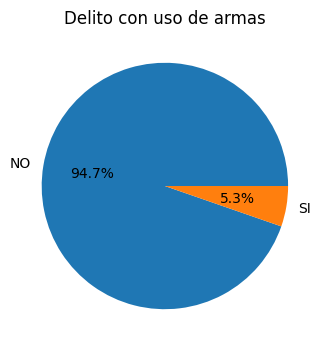

In [37]:
uso_arma = (
    df['uso_arma']
    .value_counts()
)
plt.figure(figsize=(4,4))
plt.pie(
    uso_arma.values,
    labels=['NO', 'SI'],
    autopct='%1.1f%%',
)

plt.title('Delito con uso de armas')
plt.show()

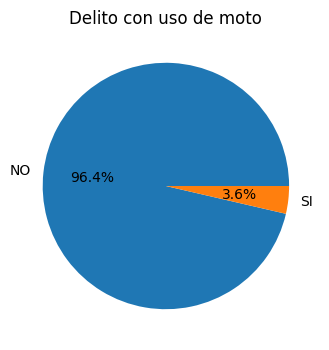

In [38]:
uso_moto = (
    df['uso_moto']
    .value_counts()
)
plt.figure(figsize=(4,4))
plt.pie(
    uso_moto.values,
    labels=['NO', 'SI'],
    autopct='%1.1f%%',
)

plt.title('Delito con uso de moto')
plt.show()

In [39]:
# 'tipo' y 'subtipo' son categorías bien definidas, no parecen campos de texto libre.
# 'tipo' 6 valores distintos
# 'subtipo' 9 valores distintos
# tengho ~159K registros.

df['tipo'] = df['tipo'].astype('category')
df['subtipo'] = df['subtipo'].astype('category')

In [40]:
df['barrio'].describe()

count      154916
unique         48
top       PALERMO
freq        12794
Name: barrio, dtype: object

In [41]:
mostrar_valores_unicos(df,['barrio','comuna'])


Columna: barrio
[1]	'PALERMO' -> 12794
[2]	'BALVANERA' -> 9967
[3]	'FLORES' -> 8509
[4]	'CABALLITO' -> 6863
[5]	'RECOLETA' -> 6690
[6]	'ALMAGRO' -> 6026
[7]	'VILLA LUGANO' -> 5861
[8]	'SAN NICOLAS' -> 5831
[9]	'BARRACAS' -> 5389
[10]	'BELGRANO' -> 5043
[11]	'VILLA CRESPO' -> 4686
[12]	'CONSTITUCION' -> 4047
[13]	'MONSERRAT' -> 3997
[14]	'PARQUE CHACABUCO' -> 3987
[15]	'RETIRO' -> 3984
[16]	nan -> 3922
[17]	'NUEVA POMPEYA' -> 3657
[18]	'MATADEROS' -> 3366
[19]	'VILLA SOLDATI' -> 3352
[20]	'VILLA URQUIZA' -> 3173
[21]	'VILLA DEVOTO' -> 3060
[22]	'LINIERS' -> 2963
[23]	'BOCA' -> 2747
[24]	'SAN CRISTOBAL' -> 2565
[25]	'PARQUE PATRICIOS' -> 2446
[26]	'SAAVEDRA' -> 2406
[27]	'CHACARITA' -> 2221
[28]	'SAN TELMO' -> 2211
[29]	'PARQUE AVELLANEDA' -> 2099
[30]	'NUÑEZ' -> 2096
[31]	'COLEGIALES' -> 2036
[32]	'BOEDO' -> 2003
[33]	'FLORESTA' -> 1878
[34]	'VILLA DEL PARQUE' -> 1830
[35]	'VILLA PUEYRREDON' -> 1598
[36]	'VILLA GRAL. MITRE' -> 1452
[37]	'VILLA LURO' -> 1437
[38]	'VELEZ SARSFIELD' -> 13

#### OJO: posibilidad de data para analizar/graficar
```
- [1]	'PALERMO' -> 12794
- [2]	'BALVANERA' -> 9967
- [3]	'FLORES' -> 8509
- [4]	'CABALLITO' -> 6863
```
##### Qué pasa con esos barrios?
>- concentración del delito
>- desigualdad territorial
>- diferencias entre comunas
>- agrupar por barrios por comunas

In [42]:
#tengo
## Barrios
# - ~159k registros
# - ~49 valores únicos de barrio
# - mucha repetición.

# en base a documentación de pandas, conviene convertirlo a categórica
df['barrio'] = df['barrio'].astype('category')

In [43]:
## Comunas
# las comunas en CABA se identifican con un número entero en el rango 1-15.
# no tiene sentido almacenarlo como float, ya que en la práctica es una variable categórica/discreta (no es contínua)
df['comuna'] = df['comuna'].astype('Int64')

In [44]:
## franja
# franja está como float, pero sólo tiene valores enteros 0-23
# franja representa la hora del delito
# al igual que comunas, lo convierto a entero (con nulos)
a= valores_unicos_a_df(df, 'franja') # uso mi funcion
a.sort_values('valor', ascending=True)

df['franja'] = df['franja'].astype('Int64')
a= valores_unicos_a_df(df, 'franja') # uso mi funcion
a.sort_values('valor', ascending=True)

,valor,cantidad
17,0,5119
20,1,3604
22,2,3002
23,3,2947
21,4,3014
19,5,3633
18,6,5043
8,7,7785
4,8,8210
11,9,7527


#### 'id-mapa'

- Esta columna es de tipo float
- En la descripción del dataset se menciona que es un indicador único

In [45]:
df['id-mapa'].count()

np.int64(158838)

In [46]:
df['id-mapa'].nunique()

158838

In [47]:
df.shape

(158838, 17)

In [48]:
# > 'id-mapa' tiene la misma cantidad de elementos únicos que la cantidad de registros
# > esto parece una PK autoincremental.
# > tomo la decisión de elimninar esa columna del análisis
df.pop('id-mapa')

0         1399612
1         1399613
2         1399614
3         1399615
4         1399616
           ...   
158833    1591956
158834    1591957
158835    1591958
158836    1591959
158837    1591960
Name: id-mapa, Length: 158838, dtype: int64

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 158838 entries, 0 to 158837
Data columns (total 16 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   anio      158838 non-null  int64         
 1   mes       158838 non-null  category      
 2   dia       158838 non-null  category      
 3   fecha     158838 non-null  datetime64[us]
 4   franja    158791 non-null  Int64         
 5   tipo      158838 non-null  category      
 6   subtipo   158838 non-null  category      
 7   uso_arma  158838 non-null  bool          
 8   uso_moto  158838 non-null  bool          
 9   barrio    154916 non-null  category      
 10  comuna    154916 non-null  Int64         
 11  latitud   155004 non-null  float64       
 12  longitud  155004 non-null  float64       
 13  cantidad  158838 non-null  int64         
 14  semana    158838 non-null  UInt32        
 15  estacion  158838 non-null  str           
dtypes: Int64(2), UInt32(1), bool(2), category(5), dat

## Como conclusión del tratamiento de los datos del dataset:
- Se trataron los campos relacionados a fecha, convirtiéndolos en tipo fecha o categóricos.
- Los campos string se transformaron en categóricos o boolean según el tipo de dato que representan.
- El campo float que almacena un número asociado a una comuna (1-15) se convirtió a entero.
  
Con estas optimizaciones, el dataframe pasó de:
```
memory usage: 18.2 MB  ->  memory usage: 11.8 MB
```


El dataset consume ahora menos recursos

Habiendo trabajado los datos, se procede a plantear preguntas sobre los datos y tratar de responderlas con gráficos

# Análisis y gráficos

**Observaciones para el tratamiento de gráficos.**

- Cada registro (fila) del DataSet corresponde a un único delito.

In [50]:
# configuracions  globales para mis gráficos
sns.set_theme(style="whitegrid")

## `lineplot` Evolución de reporte de delitos por día

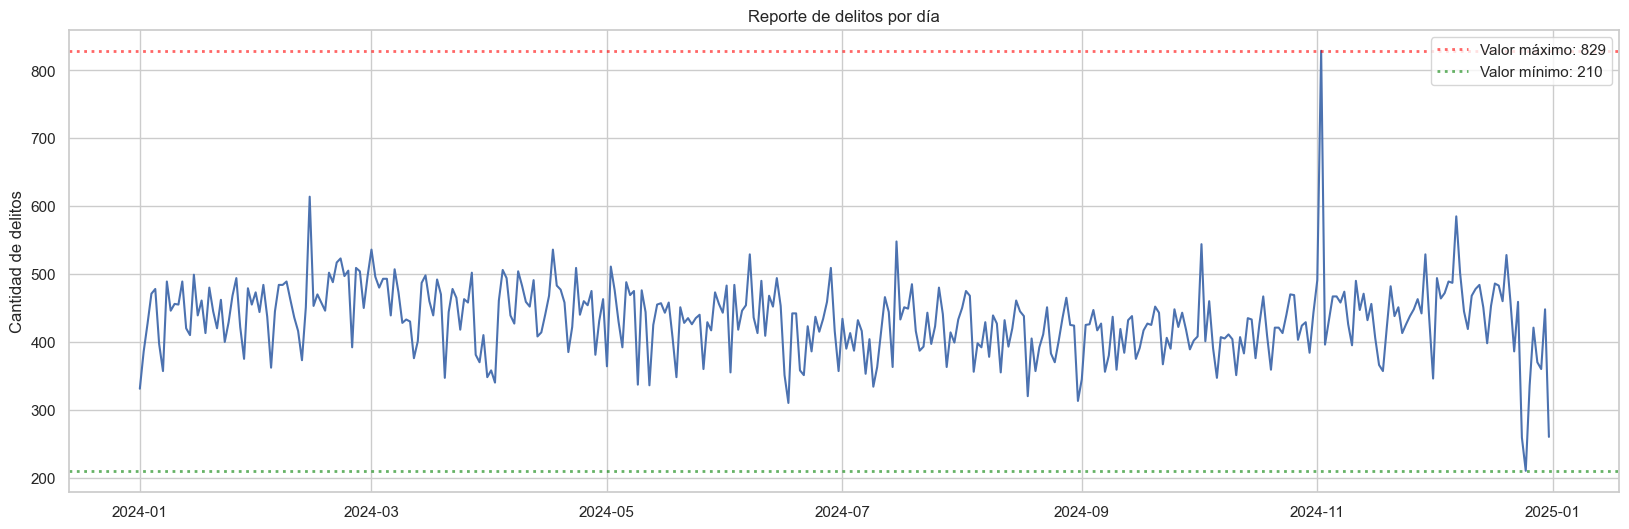

In [51]:
# delitos por fecha: armo un grafico de líneas mostrando el total de delitos de cada día.
delitos_fecha = (
    df.groupby('fecha')['cantidad']
    .sum()
    .reset_index()
)

plt.figure(figsize=(20, 6))

sns.lineplot(
    data=delitos_fecha,
    x='fecha',
    y='cantidad'
)

# busco los máximo y mínimo, porque me gustaría graficarlos
maximo = delitos_fecha['cantidad'].max()
minimo = delitos_fecha['cantidad'].min()

# Dibujar líneas horizontales
plt.axhline(
    y=maximo,
    linestyle='dotted',
    label=f'Valor máximo: {maximo}',
    alpha=0.6,
    color ='red',
    linewidth=2,
)

plt.axhline(
    y=minimo,
    linestyle='dotted',
    label=f'Valor mínimo: {minimo}',
    alpha=0.6,
    color ='green',
    linewidth=2,
)

plt.legend()

plt.title('Reporte de delitos por día')
plt.xlabel('')
plt.ylabel('Cantidad de delitos')

plt.show()

- No se observa una distribución normal para la cantidad de delitos.
- En los meses de noviembre y diciembre se observan valores atípicamente altos y bajos (buscar de representar los outliers)

## `boxplot` Distribución de los delitos por mes, con ouliers

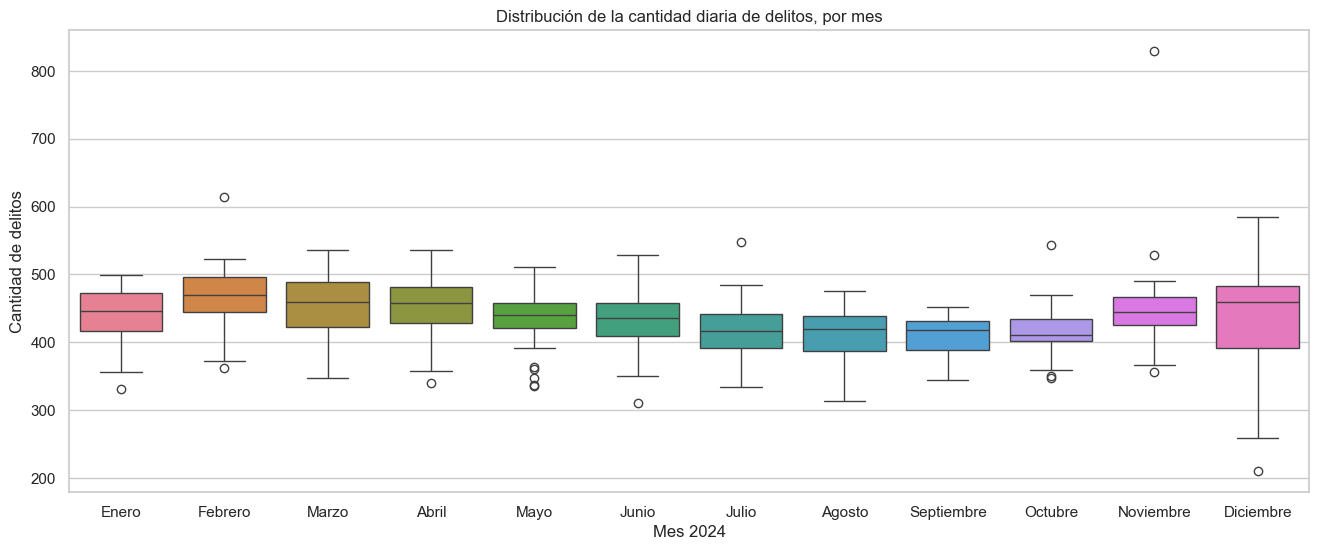

In [157]:
# pueddo mostrar estos outliers con un boxplot?
df_boxplot_mes = (
    df.groupby(['fecha', 'mes'], observed=True)
      .size()
      .reset_index(name='cantidad_delitos')
)

# Crear gráfico
plt.figure(figsize=(16, 6))

sns.boxplot(
    data=df_boxplot_mes,
    x='mes',
    y='cantidad_delitos',
    hue='mes', # con esto, hago que cada mes tenga un color diferente
    dodge=False, # hago que cada caja quede centrada con su tick en el eje x
)

plt.title('Distribución de la cantidad diaria de delitos, por mes')
plt.xlabel('Mes 2024')
plt.ylabel('Cantidad de delitos')

plt.show()

In [149]:
# me apoyo con valores para contrastar el gráfico
df_apoyo = (
    df.groupby(['fecha', 'mes'], observed=True)
      .size()
      .reset_index(name='cantidad_delitos')
)

# el método pivot():
# reorganiza el DataFrame utilizando
# - 'fecha' como índice
# - los valores de 'mes' como columnas
# - y 'cantidad_delitos' como valores de las celdas.
#
# Cada celda representa la cantidad de delitos registrados
# para una fecha y mes determinados.
#
# >>>> al pivot se le llama también 'formato ancho?'

df_mes = df_apoyo.pivot(
    index='fecha',
    columns='mes',
    values='cantidad_delitos'
)

df_mes.describe()

mes,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
count,31.000000,29.000000,31.000000,30.000000,31.000000,30.000000,31.000000,31.000000,30.000000,31.000000,30.000000,31.000000
mean,439.548387,468.689655,448.870968,450.600000,431.709677,429.133333,418.322581,409.935484,410.233333,417.451613,454.833333,431.000000
std,41.907707,49.574694,48.941286,45.315446,44.384827,52.607678,43.623684,41.803457,29.997337,39.352966,79.560033,82.373539
min,331.000000,362.000000,347.000000,340.000000,336.000000,310.000000,334.000000,313.000000,345.000000,347.000000,357.000000,210.000000
25%,416.500000,445.000000,423.000000,428.000000,421.000000,410.000000,391.500000,387.500000,389.250000,402.000000,426.000000,392.000000
50%,446.000000,470.000000,460.000000,458.500000,440.000000,436.500000,416.000000,420.000000,418.500000,411.000000,444.500000,459.000000
75%,472.000000,497.000000,489.500000,481.500000,457.500000,457.750000,442.000000,438.500000,430.750000,434.000000,467.000000,483.500000
max,499.000000,614.000000,536.000000,536.000000,511.000000,529.000000,548.000000,475.000000,452.000000,544.000000,829.000000,585.000000


### Conclusiones
- las medianas mensuales se mantienen relativamente estables durante todo el año (~400-480 delitos diarios).
- el mes de diciembre presenta una dispersión notablemente mayor que el resto
- outliers
  - meses con valores aislados (outliers) inferiores: enero, febrero, abril, mayo, junio, octubre, noviembre, diciembre
  - meses con valores aislados (outliers) superiores: febrero, julio, octubre, noviembre, diciembre
  - noviembre contiene el valor atípico más extremo de todo el año, superando los 800 delitos diarios.
  - diciembre, en cambio, muestra el valor atípico inferior más extremos del año, con ~200 delitos diarios

## `barplot` Totales de delitos por mes

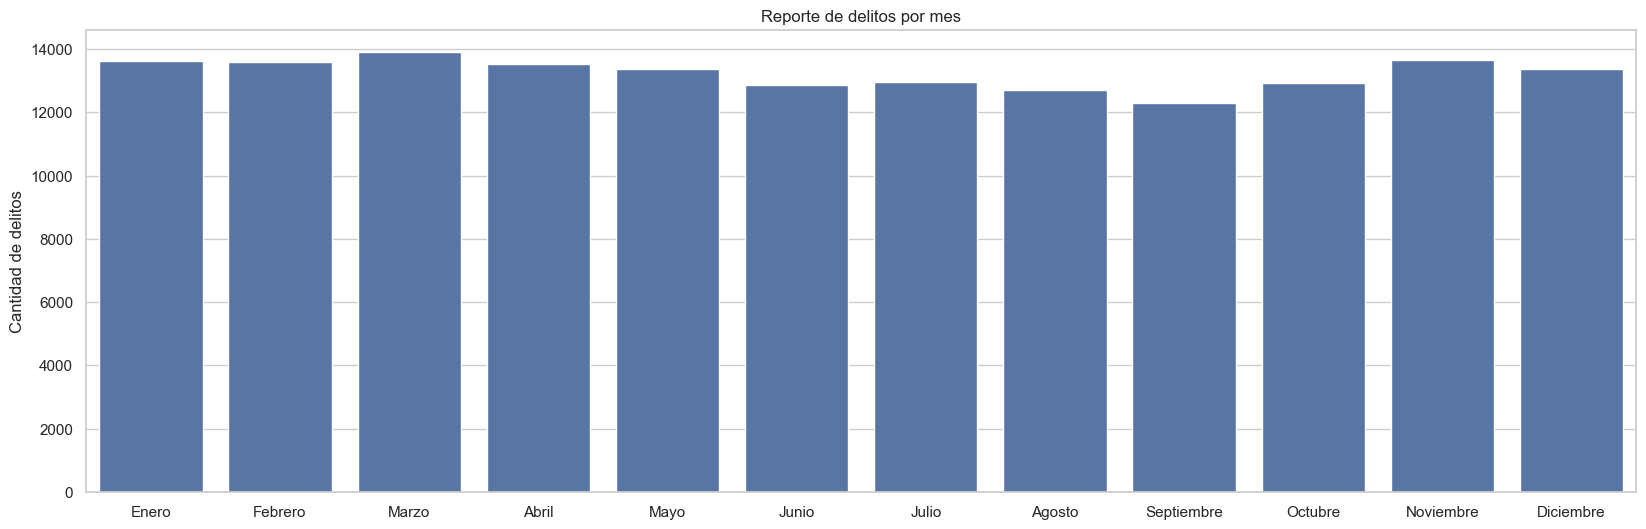

In [54]:
# Delitos por mes
delitos_mes = (
    df.groupby('mes')['cantidad']
    .sum()
    .reset_index()
)

plt.figure(figsize=(20, 6))

sns.barplot(
    data=delitos_mes,
    x='mes',
    y='cantidad',
    #hue='mes', dodge=False, palette='Accent'
)

plt.title('Reporte de delitos por mes')
plt.xlabel('')
plt.ylabel('Cantidad de delitos')
plt.show()

In [55]:
delitos_mes.describe()

,cantidad
count,12.000000
mean,13236.500000
std,472.481938
min,12307.000000
25%,12924.250000
50%,13372.000000
75%,13600.500000
max,13915.000000


- No se observa una distribución normal de la cantidad de delitos según el mes del año.
- Se observa un comportamiento relativamente estable.

*Voy a hacer el mismo gráfico pero por semana a ver si cambia algo*

## `barplot` Cantidad de delitos por semana

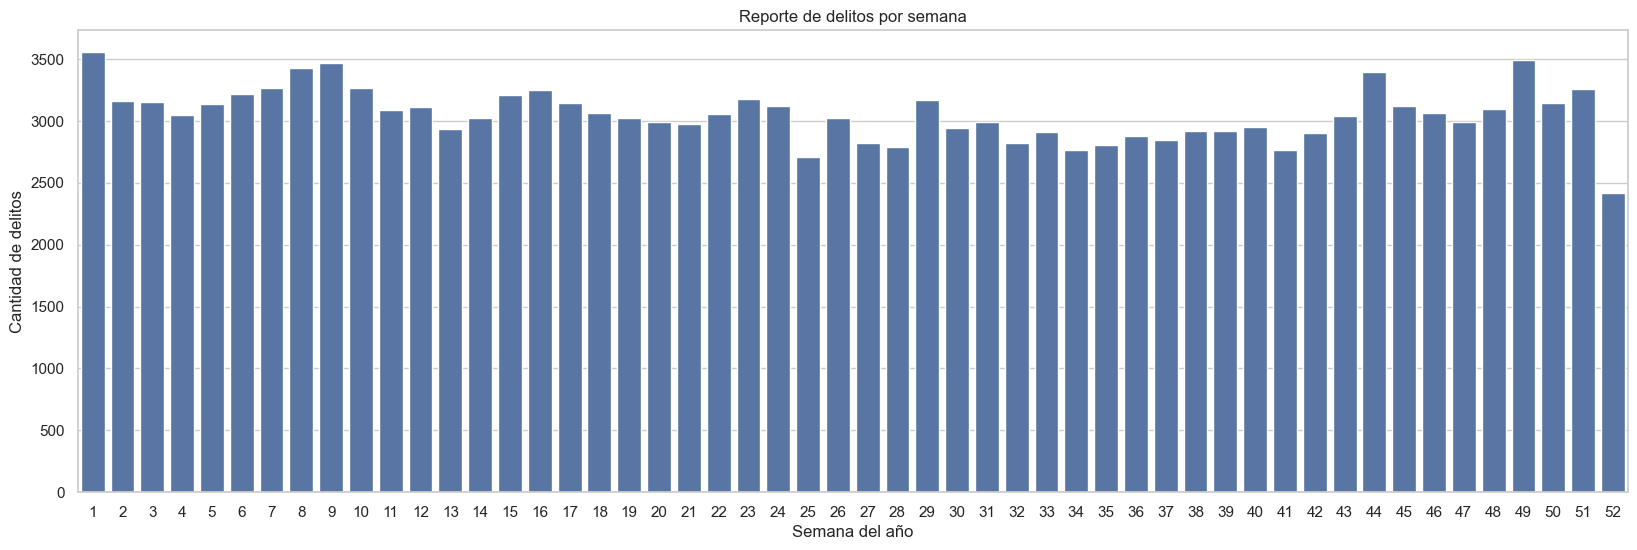

In [56]:
delitos_semana = (
    df.groupby('semana')['cantidad']
    .sum()
    .reset_index()
)
#delitos_semana
plt.figure(figsize=(20, 6))

sns.barplot(
    data=delitos_semana,
    x='semana',
    y='cantidad',
)

plt.title('Reporte de delitos por semana')
plt.xlabel('Semana del año')
plt.ylabel('Cantidad de delitos')
plt.show()

## `histplot_kde` Concentración y distribución de delitos a lo largo del año

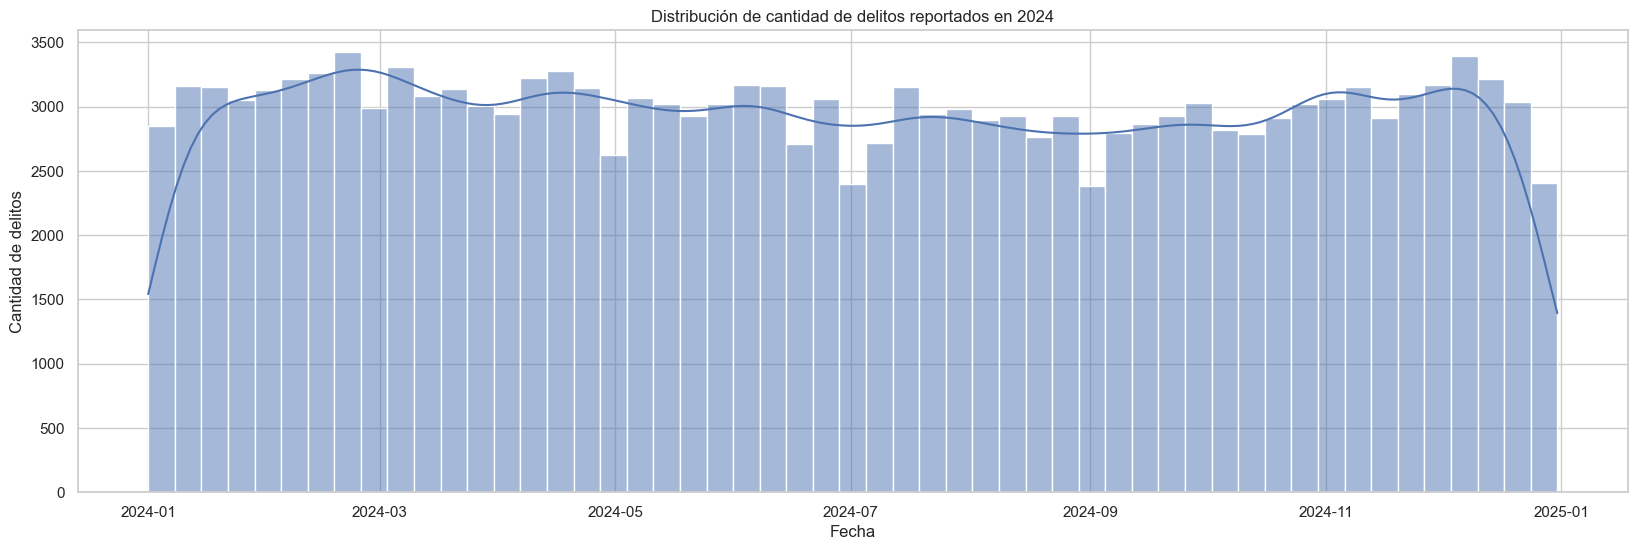

In [57]:
plt.figure(figsize=(20, 6))

# No tengo auq hacer nada con los datos, sólo graficarlos
sns.histplot(
    data=df,
    #bins=120,
    x='fecha',
    #hue='estacion',
    legend=False,
    kde=True,
) 

plt.title('Distribución de cantidad de delitos reportados en 2024')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de delitos')
plt.show()

- La cantidad diaria de delitos reportados durante 2024 presenta un comportamiento relativamente estable.
- Preenta varioaciones moderadas a lo largo del año.
- Se observan leves incrementos en determinados períodos, especialmente al inicio y final del año
- Los meses de mayo, julio y septiembre muestran una ligera reducción en la frecuencia diaria.

## `lineplot` Reporte de delitos por día y tipo de delito

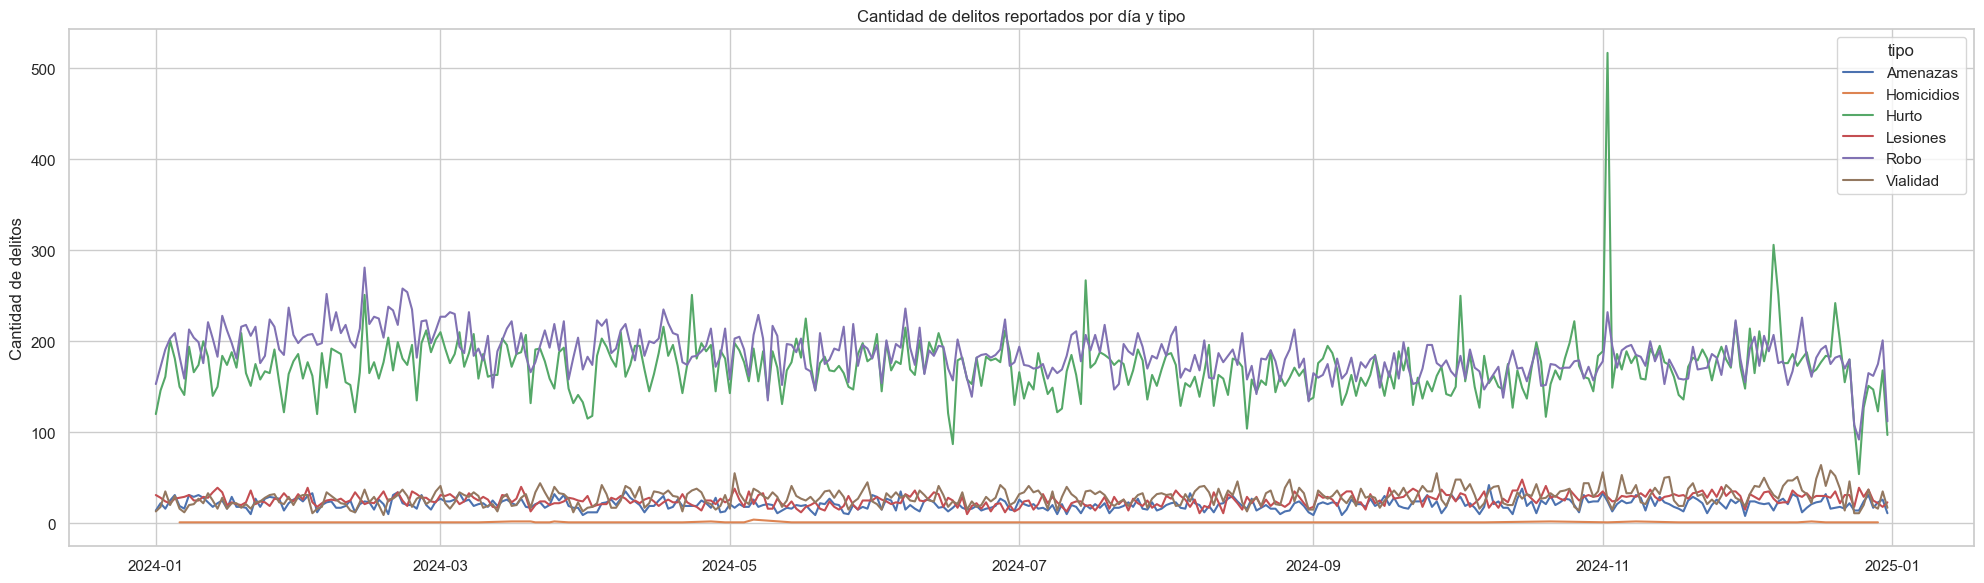

In [58]:
# Agrupar por fecha y tipo de delito
delitos_fecha_tipo = (
    df.groupby(['fecha', 'tipo'], observed=True)['cantidad']
    .sum()
    .reset_index()
)

plt.figure(figsize=(20, 6))

sns.lineplot(
    data=delitos_fecha_tipo,
    x='fecha',
    y='cantidad',
    hue='tipo',
    #palette='Accent'
)

# Títulos y etiquetas
plt.title('Cantidad de delitos reportados por día y tipo')
plt.xlabel('')
plt.ylabel('Cantidad de delitos')

plt.tight_layout()
plt.show()

## `histplot_kde` Distribución de delitos según hora de ocurrencia

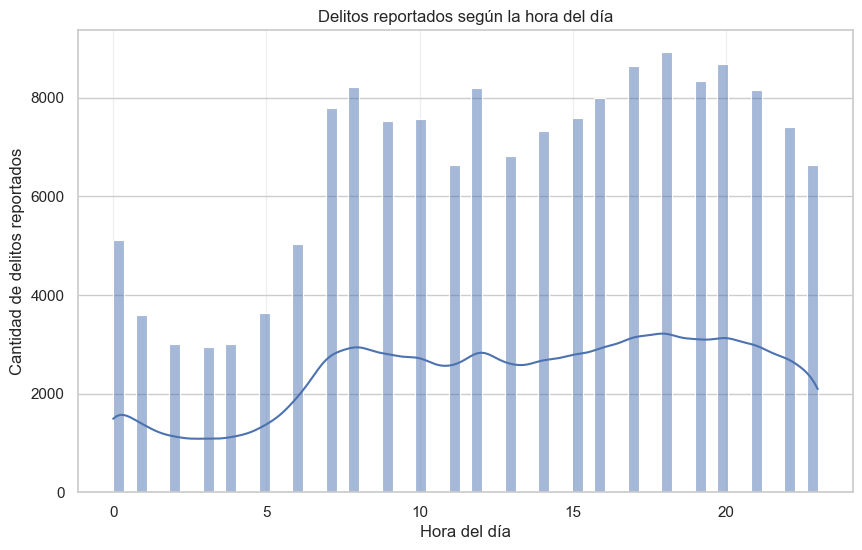

In [59]:
plt.figure(figsize=(10, 6))

ax = sns.histplot(data=df, x='franja', kde=True) #en 'franja' está la hora

plt.title('Delitos reportados según la hora del día')
plt.xlabel('Hora del día')
plt.ylabel('Cantidad de delitos reportados')
plt.grid(axis='x', alpha=0.3)

plt.show()

#### Análisis/conclusiones
- No se observa una distribución normal.
- El momento del día de **menor ocurrencia** de delitos se da por la madrugada, **de 1 a 5**.
- El momento del día de **mayor ocurrencia** de delitos se da pasada las **5 de la mañana**.

## `heatmap` Mapa de calor de delitos por hora

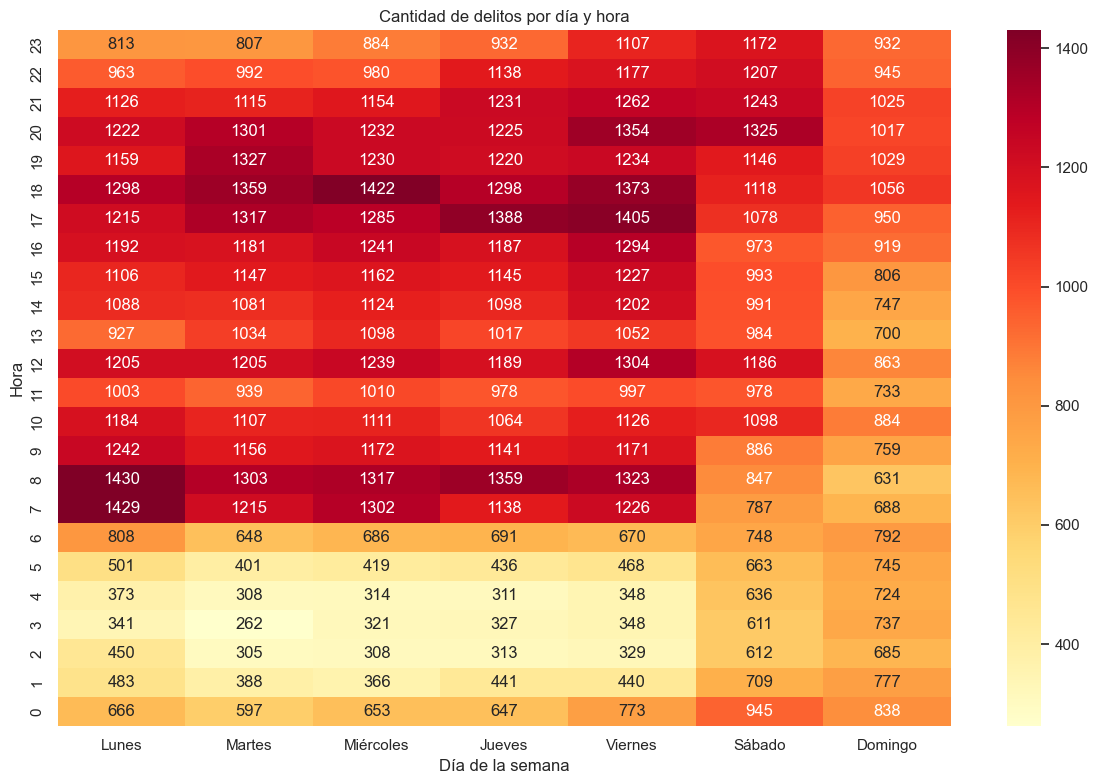

In [60]:
df_heatmap = pd.crosstab(
    df['franja'],
    df['dia']
)

# Gráfico
plt.figure(figsize=(12,8))

ax = sns.heatmap(
    df_heatmap,
    annot=True,      # muestra valores
    fmt='d',         # enteros
    cmap='YlOrRd'
)

ax.invert_yaxis() # hago esto para que las 0 aparezcan en la parte de abajo y las 23 arriba

plt.title('Cantidad de delitos por día y hora')
plt.xlabel('Día de la semana')
plt.ylabel('Hora')


plt.tight_layout()
plt.show()

En este mapa de calor se observa con mayor nivel de detalle que:
- la menor concentración de delitos se da de lunes a viernes entre la 1 y las 5 de la mañana
- la mayor concentración de delitos se da:
  - de lunes a viernes de 6 a 23
  - sábados a partir de ~10
- el comportamiento del día domingo presenta una dinámica distinta respecto de los días laborales.

## Delitos por barrio

## `barplot` Hay barrios que concentren más delitos que otros?

In [61]:
df['barrio'].nunique # Cantidad de barrios

<bound method IndexOpsMixin.nunique of 0                 CHACARITA
1                 CHACARITA
2                 MATADEROS
3                   PALERMO
4               SAN NICOLAS
                ...        
158833             RECOLETA
158834        NUEVA POMPEYA
158835         CONSTITUCION
158836             BARRACAS
158837    PARQUE AVELLANEDA
Name: barrio, Length: 158838, dtype: category
Categories (48, str): ['AGRONOMIA', 'ALMAGRO', 'BALVANERA', 'BARRACAS', ..., 'VILLA RIACHUELO', 'VILLA SANTA RITA', 'VILLA SOLDATI', 'VILLA URQUIZA']>

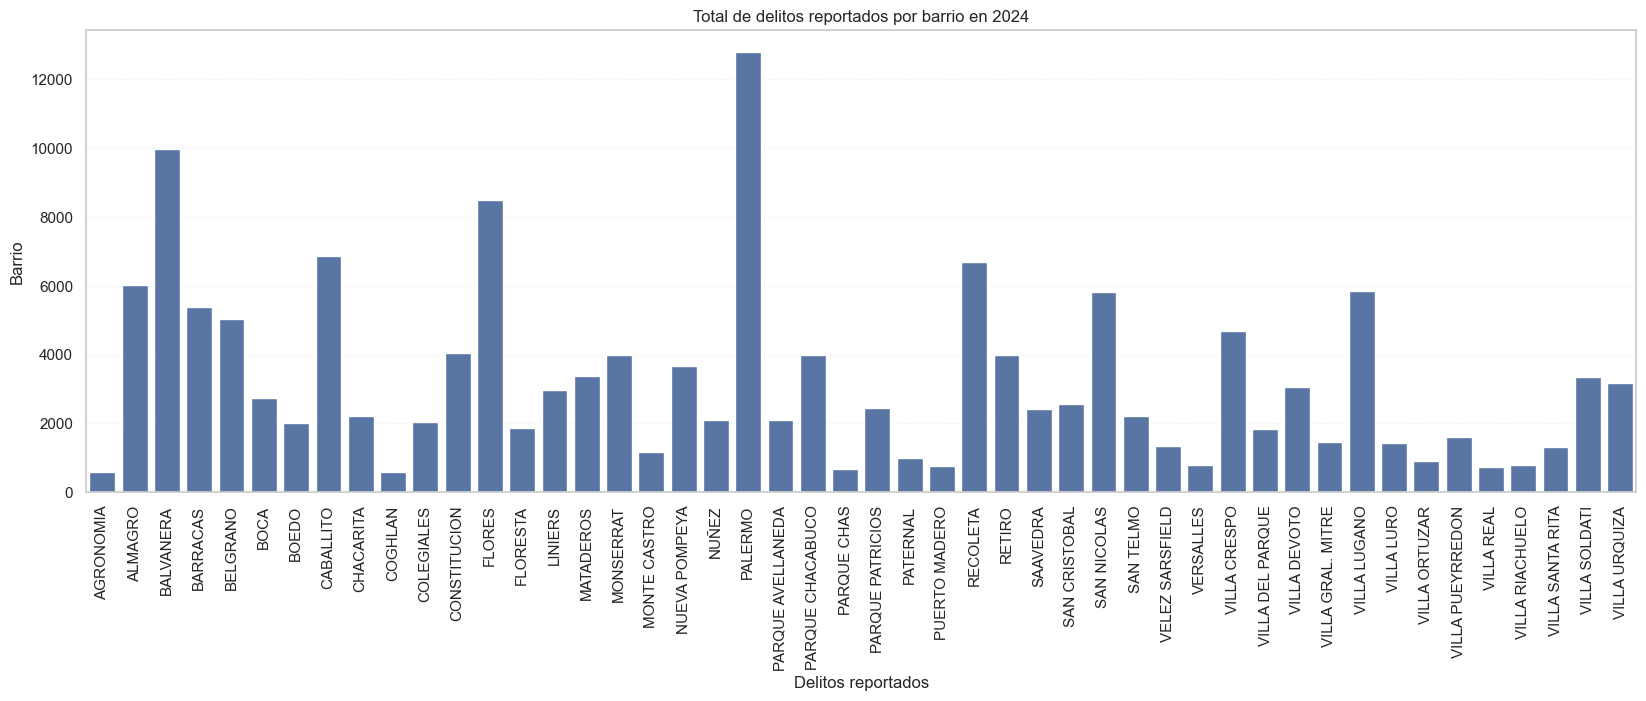

In [62]:
# Delitos por barrio
delitos_barrio = (
    df.groupby('barrio', observed=True)['cantidad']
    .sum()
    .reset_index() # esto me convierte el 'pandas.Series' a un 'pandas.DataFrame'
)
plt.figure(figsize=(20, 6))

sns.barplot(
    data=delitos_barrio,
    x='barrio',
    y='cantidad',
)
plt.title('Total de delitos reportados por barrio en 2024')
plt.xlabel('Delitos reportados')
plt.ylabel('Barrio')

plt.grid(axis='y',alpha=0.3, linestyle='dotted')
plt.xticks(rotation=90)


plt.show()

En Palermo, Balvanera y FLores se observa la mayor cantidad de delitos reportados en el año

## `barplot`+`lineplot` Diagrama de Pareto

In [63]:
# puedo armar un Pareto ? --> parte 1 (datos)
total_delitos = delitos_barrio['cantidad'].sum()
total_barrios = len(delitos_barrio)

# ordeno 'delitos_barios' por 'cantidad' descendente
barrios = delitos_barrio.sort_values(
    by='cantidad',
    ascending=False
).reset_index(drop=True) # hago "reset_index(drop=True)"  para tenerun datafreame

# delitos acumulados: creo la columna donde voy calculando el acumulado de delitos
barrios['cantidad_acumulada'] = barrios['cantidad'].cumsum()

# porcentaje individual: pordentaje de delitos de este barrio sobre el total
barrios['porcentaje'] = barrios['cantidad'] / total_delitos * 100

# porcentaje acumulado: porcentaje acumulado de cantidad de delitos
barrios['porcentaje_acumulado'] = barrios['porcentaje'].cumsum()

# imprimo algunos valores para saber qué puedo graficar después
corte = 55 # a dónde quiero mi corte, en %

barrios_corte = barrios[barrios['porcentaje_acumulado'] <= corte]

barrios_p = len(barrios_corte)
porcentaje_barrios = barrios_p / total_barrios * 100

print (f"Cantidad barrios: {total_barrios}")
print (f"Total de delitos: {total_delitos}")
print (f"Cantidad de barrios que acumulan {corte}% de los delitos: {barrios_p}")
print (f"Porcentaje de barrios que acumulan {corte}% de los delitos: {porcentaje_barrios:.2f}% ({barrios_p}/{total_barrios})")
barrios_corte

Cantidad barrios: 48
Total de delitos: 154916
Cantidad de barrios que acumulan 55% de los delitos: 12
Porcentaje de barrios que acumulan 55% de los delitos: 25.00% (12/48)


,barrio,cantidad,cantidad_acumulada,porcentaje,porcentaje_acumulado
0,PALERMO,12794,12794,8.258669,8.258669
1,BALVANERA,9967,22761,6.433809,14.692479
2,FLORES,8509,31270,5.492654,20.185133
3,CABALLITO,6863,38133,4.430143,24.615275
4,RECOLETA,6690,44823,4.318469,28.933745
5,ALMAGRO,6026,50849,3.889850,32.823595
6,VILLA LUGANO,5861,56710,3.783341,36.606935
7,SAN NICOLAS,5831,62541,3.763975,40.370911
8,BARRACAS,5389,67930,3.478659,43.849570
9,BELGRANO,5043,72973,3.255313,47.104883


In [64]:
# Para el análisis voy a considerar VILLA CRESPO; lo tengo que destacar luego

# cómo me quedaron los datos?
print (barrios.head(2))
print (barrios.tail(2))
barrios.describe()

      barrio  cantidad  cantidad_acumulada  porcentaje  porcentaje_acumulado
0    PALERMO     12794               12794    8.258669              8.258669
1  BALVANERA      9967               22761    6.433809             14.692479
       barrio  cantidad  cantidad_acumulada  porcentaje  porcentaje_acumulado
46    COGHLAN       592              154331    0.382143             99.622376
47  AGRONOMIA       585              154916    0.377624            100.000000


,cantidad,cantidad_acumulada,porcentaje,porcentaje_acumulado
count,48.000000,48.000000,48.000000,48.000000
mean,3227.416667,110485.208333,2.083333,71.319430
std,2581.326056,40205.433981,1.666275,25.953055
min,585.000000,12794.000000,0.377624,8.258669
25%,1417.000000,84703.750000,0.914689,54.677212
50%,2426.000000,122206.000000,1.566010,78.885331
75%,4009.500000,144609.250000,2.588177,93.346878
max,12794.000000,154916.000000,8.258669,100.000000


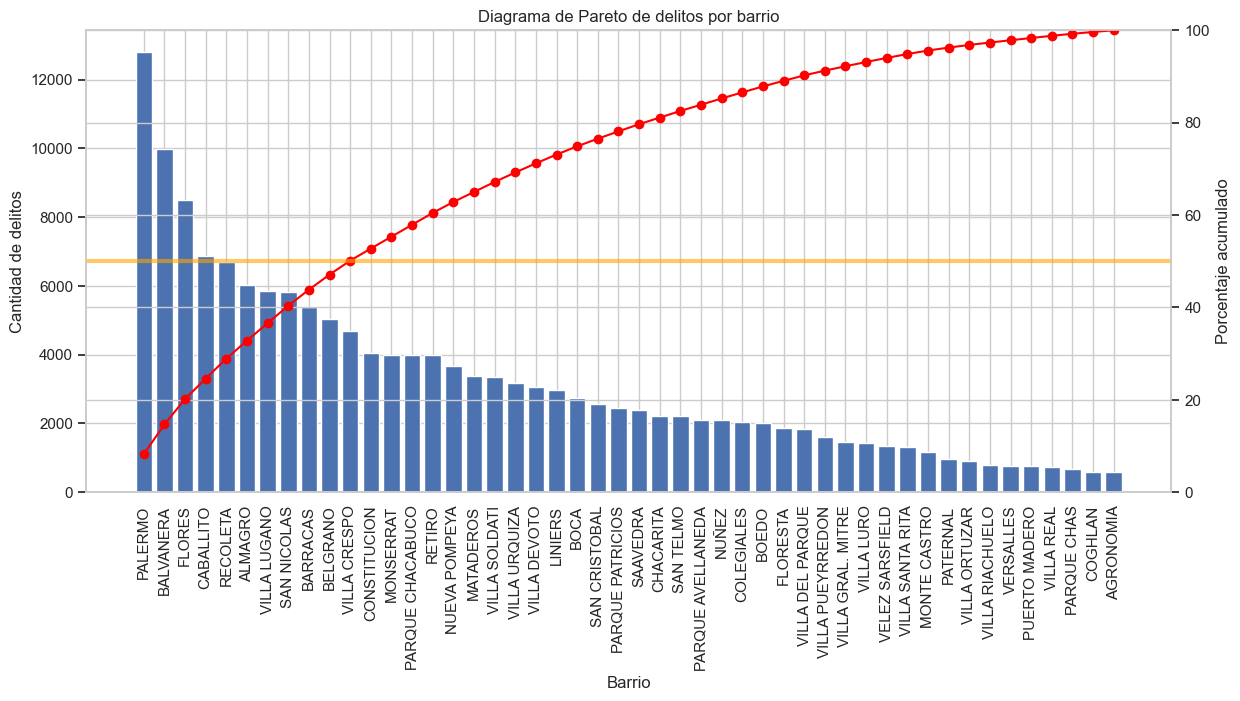

In [65]:
# puedo armar un Pareto ? --> parte 2 (gráfico)

# tengo que armar subplots para meter más de 1 gráfico en eun lienzop
# el subplot es una forma de colocar múltiples gráficos dentro de una misma figura (figure)
fig, ax1 = plt.subplots(figsize=(14,6))

# Barras (frecuencia)
ax1.bar(barrios['barrio'], barrios['cantidad'])

# Eje izquierdo
ax1.set_ylabel('Cantidad de delitos')
ax1.set_xlabel('Barrio')

# Rotar etiquetas poque se ven feas si están en horizntal
plt.xticks(rotation=90)

# eje derecho para porcentaje acumulado
ax2 = ax1.twinx()

# Línea acumulada
ax2.plot(
    barrios['barrio'],
    barrios['porcentaje_acumulado'],
    marker='o',
    color='red'
)

# Línea horizontal del % que quiero 
#ax2.axhline(80, linestyle='solid', color='orange',linewidth=3, alpha=0.6)
ax2.axhline(50, linestyle='solid', color='orange',linewidth=3, alpha=0.6)

# Eje derecho
ax2.set_ylabel('Porcentaje acumulado')
ax2.set_ylim(0, 100)
plt.title('Diagrama de Pareto de delitos por barrio')

plt.show()

**11 barrios** concentran el **50% de los delitos** reportados en CABA en 2024

**NOTA**: En el gráfico, el valor cae sobre VILLA CRESPO, sin embargo en los datos se observa que:
```
barrio 	cantidad 	cantidad_acumulada 	porcentaje 	porcentaje_acumulado
0 	PALERMO 	12794 	12794 	8.258669 	8.258669
1 	BALVANERA 	9967 	22761 	6.433809 	14.692479
2 	FLORES 		8509 	31270 	5.492654 	20.185133
3 	CABALLITO 	6863 	38133 	4.430143 	24.615275
4 	RECOLETA 	6690 	44823 	4.318469 	28.933745
5 	ALMAGRO 	6026 	50849 	3.889850 	32.823595
6 	VILLA LUGANO 	5861 	56710 	3.783341 	36.606935
7 	SAN NICOLAS 	5831 	62541 	3.763975 	40.370911
8 	BARRACAS 	5389 	67930 	3.478659 	43.849570
9 	BELGRANO 	5043 	72973 	3.255313 	47.104883
10 	VILLA CRESPO 	4686 	77659 	3.024865 	50.129748
```

Se considera, para este análisis que el 0.129748 % es marginal y se entiende a VILLA CRESPO dentro de los barrios que explican el 50% del análisis, a pesar de superar de la cota del 50%

## Delitos por comuna

## `barplot` Hay comunas que concentren más delitos que otras?

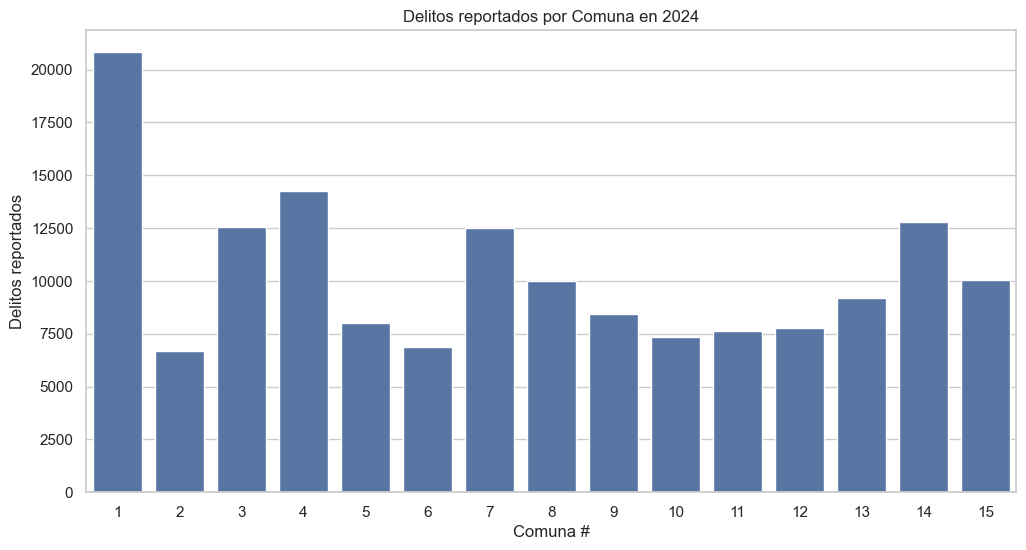

In [156]:
# Delitos por comuna
delitos_comuna = (
    df.groupby('comuna')['cantidad']
    .sum()
    .sort_values(ascending=False)
    .reset_index() # esto me convierte el 'pandas.Series' a un 'pandas.DataFrame'
)

# esto lo genero para poder ordenar luego por cantidad de de ltios.

delitos_comuna_orden = delitos_comuna['comuna']

plt.figure(figsize=(12, 6))

sns.barplot(
    data=delitos_comuna,
    x='comuna',
    y='cantidad',
    legend=False
)

plt.title('Delitos reportados por Comuna en 2024')
plt.xlabel('Comuna #')
plt.ylabel('Delitos reportados')

plt.show()

La distribución de delitos por comuna no presenta una distribución normal

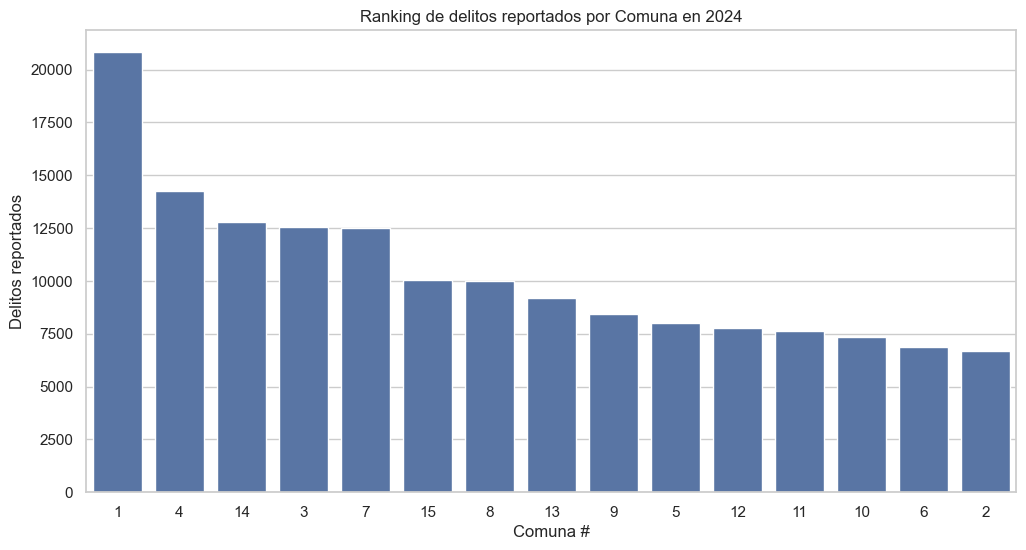

In [67]:
# y ordenado por cantidad de delitos descendente:
delitos_comuna_orden = delitos_comuna['comuna']

plt.figure(figsize=(12, 6))

sns.barplot(
    data=delitos_comuna,
    x='comuna',
    y='cantidad',
    order=delitos_comuna_orden,
    legend=False
)

plt.title('Ranking de delitos reportados por Comuna en 2024')
plt.xlabel('Comuna #')
plt.ylabel('Delitos reportados')

plt.show()

Las tres Comunas con la mayor cantiad de delitos reportados en 2024 son 1, 4 y 14

**Comunas según Gobierno de la Ciudad de Buenos Aires**: [https://buenosaires.gob.ar/gcaba_historico/gobierno/gestion-comunal/comunas]
```
Comuna 1: Retiro, San Nicolás, Puerto Madero, San Telmo, Montserrat y Constitución
Comuna 2: Recoleta
Comuna 3: Balvanera y San Cristóbal
Comuna 4: La Boca, Barracas, Parque Patricios, y Nueva Pompeya
Comuna 5: Almagro y Boedo
Comuna 6: Caballito
Comuna 7: Flores y Parque Chacabuco
Comuna 8: Villa Soldati, Villa Riachuelo y Villa Lugano
Comuna 9: Liniers, Mataderos y Parque Avellaneda
Comuna 10: Villa Real, Monte Castro, Versalles, Floresta, Vélez Sarsfield y Villa Luro
Comuna 11: Villa General Mitre, Villa Devoto, Villa del Parque y Villa Santa Rita
Comuna 12: Coghlan, Saavedra, Villa Urquiza y Villa Pueyrredón
Comuna 13: Núñez, Belgrano y Colegiales
Comuna 14: Palermo
Comuna 15: Chacarita, Villa Crespo, La Paternal, Villa Ortúzar, Agronomía y Parque Chas
```

## `barplot` Delitos por tipo de delito

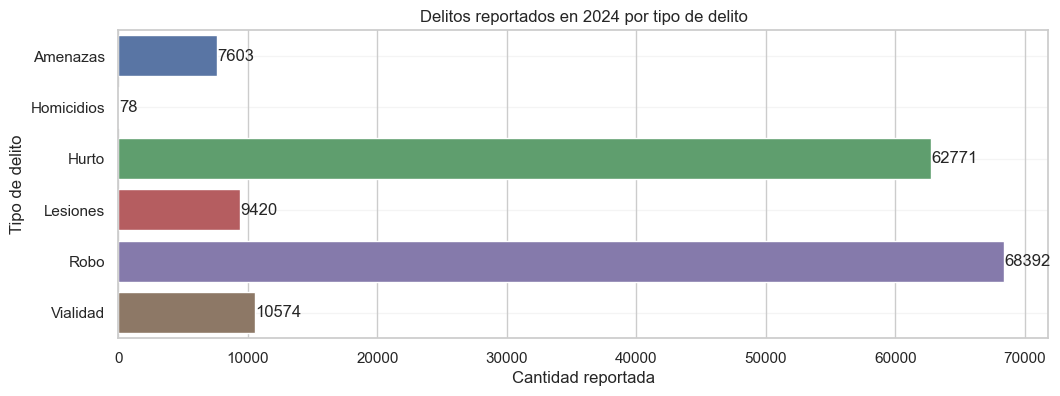

In [68]:
# Agrupar datos
delitos_tipo = (
    df.groupby('tipo', observed=True)['cantidad']
    .sum()
    .reset_index()
)

# Figura
plt.figure(figsize=(12, 4))

# Gráfico
ax = sns.barplot(
    data=delitos_tipo,
    y='tipo',
    x='cantidad',
    hue='tipo',
    dodge=False,
    #legend=True # no es necesario usar 'legend' en este gráfico
)

# Títulos y etiquetas
plt.title('Delitos reportados en 2024 por tipo de delito')
plt.xlabel('Cantidad reportada')
plt.ylabel('Tipo de delito')

# Grid
plt.grid(axis='y', alpha=0.2)

# Con este bucle escribo los valores de cada barra, es útil porque 'homicidios' 
# tiene un valor de 78 mientras que el resto tiene valors de al menos 4 dígitos
for container in ax.containers:
    ax.bar_label(container)

plt.show()

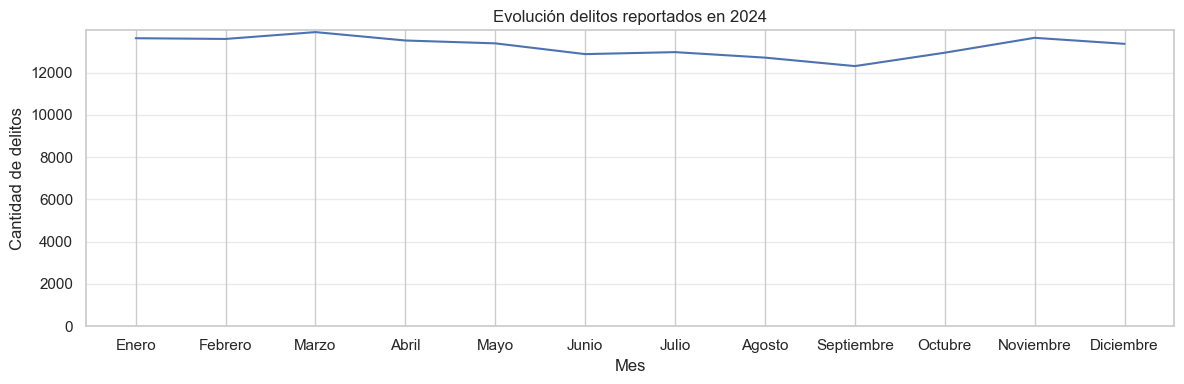

In [69]:
delitos_mes = (
    df.groupby('mes')['cantidad']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 4))

sns.lineplot(
    data=delitos_mes,
    x='mes',
    y='cantidad'
)

plt.title('Evolución delitos reportados en 2024')
plt.xlabel('Mes')
plt.ylabel('Cantidad de delitos')
plt.ylim(bottom=0)   # Inicia eje Y en 0
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()

plt.show()

# XXXXXXXXXXXX

In [70]:
df.sample(5)

,anio,mes,dia,fecha,franja,tipo,subtipo,uso_arma,uso_moto,barrio,comuna,latitud,longitud,cantidad,semana,estacion
90761,2024,Septiembre,Viernes,2024-09-06,20,Robo,Robo total,False,False,FLORES,7,-34.650820,-58.454637,1,36,Invierno
68098,2024,Julio,Lunes,2024-07-01,11,Hurto,Hurto total,False,False,SAN NICOLAS,1,-34.604163,-58.375131,1,27,Invierno
140488,2024,Diciembre,Viernes,2024-12-27,12,Lesiones,Lesiones Dolosas,False,False,COLEGIALES,13,-34.567854,-58.449047,1,52,Verano
71011,2024,Julio,Jueves,2024-07-11,13,Hurto,Hurto total,False,False,MONSERRAT,1,-34.610964,-58.391737,1,28,Invierno
142155,2024,Marzo,Martes,2024-03-12,14,Amenazas,Amenazas,False,False,LINIERS,9,-34.642762,-58.524344,1,11,Verano


In [71]:
df[df['dia'] == 'Lunes'].sample(5)

,anio,mes,dia,fecha,franja,tipo,subtipo,uso_arma,uso_moto,barrio,comuna,latitud,longitud,cantidad,semana,estacion
157021,2024,Abril,Lunes,2024-04-22,21,Vialidad,Lesiones por siniestros viales,False,False,VILLA URQUIZA,12,-34.574685,-58.501474,1,17,Otoño
151690,2024,Mayo,Lunes,2024-05-06,17,Vialidad,Lesiones por siniestros viales,False,False,BOEDO,5,-34.627872,-58.415940,1,19,Otoño
32071,2024,Marzo,Lunes,2024-03-25,18,Hurto,Hurto total,False,False,FLORES,7,-34.623919,-58.475813,1,13,Otoño
133584,2024,Abril,Lunes,2024-04-01,11,Lesiones,Lesiones Dolosas,False,False,CABALLITO,6,-34.627936,-58.450562,1,14,Otoño
50184,2024,Mayo,Lunes,2024-05-13,20,Robo,Robo total,False,False,PALERMO,14,-34.587307,-58.438540,1,20,Otoño


In [153]:
# Voy a tener que hacer algo con los datos para tener una variable con valores distintos para ver su comportamiento

In [154]:
# agrupo los datos por fecha

In [155]:
dfb = (
    df.groupby(['fecha'], observed=True)
      .size()
      .reset_index(name='cantidad')
)
#dfb[dfb['dia'] == 'Lunes']
dfb

,fecha,cantidad
0,2024-01-01,331
1,2024-01-02,386
2,2024-01-03,427
3,2024-01-04,471
4,2024-01-05,478
...,...,...
361,2024-12-27,421
362,2024-12-28,370
363,2024-12-29,360
364,2024-12-30,448


## `boxplot` Delitos por día de la semana

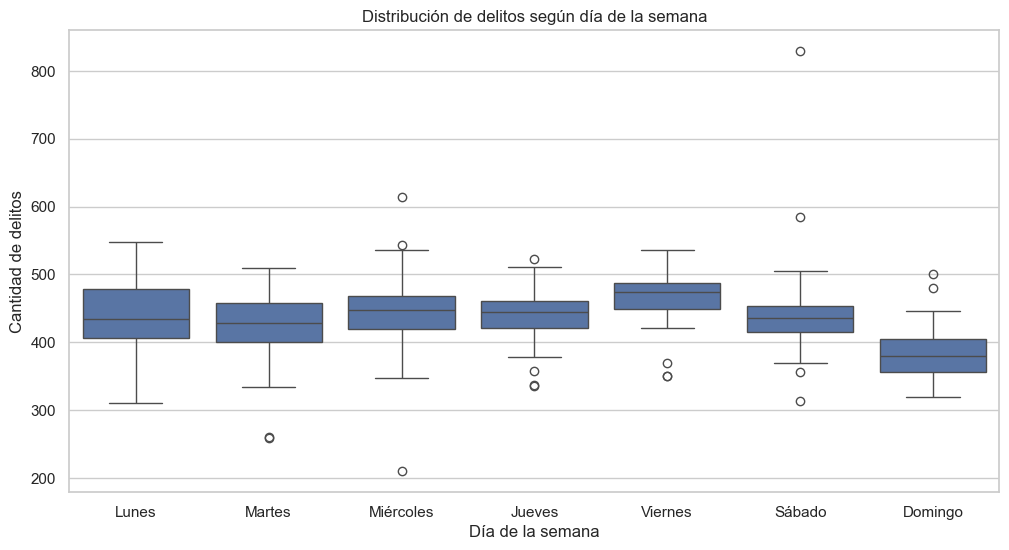

In [147]:
# Agrupar delitos por fecha y día
df_boxplot = (
    df.groupby(['fecha', 'dia'], observed=True)
      .size()
      .reset_index(name='cantidad_delitos')
)

# Crear gráfico
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_boxplot,
    x='dia',
    y='cantidad_delitos',
    #hue='dia'
    #order=orden_dias
)

plt.title('Distribución de delitos según día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Cantidad de delitos')

plt.show()

Conclusiones

- puede observarse que la cantidad de delitos presenta variaciones moderadas entre los distintos días de la semana, aunque existen ciertos patrones relevantes
- La mediana —la línea horizontal dentro de cada caja— indica que los viernes concentran la mayor cantidad típica de delitos diarios
- 
    
    las medianas mensuales se mantienen relativamente estables durante todo el año (~400-480 delitos diarios).
    el mes de diciembre presenta una dispersión notablemente mayor que el resto
    outliers
        meses con valores aislados (outliers) inferiores: enero, febrero, abril, mayo, junio, octubre, noviembre, diciembre
        meses con valores aislados (outliers) superiores: febrero, julio, octubre, noviembre, diciembre
        noviembre contiene el valor atípico más extremo de todo el año, superando los 800 delitos diarios.
        diciembre, en cambio, muestra el valor atípico inferior más extremos del año, con ~200 delitos diarios


## `lineplot` Delitos de Vialidad, por semana

        anio         mes     dia      fecha  franja      tipo  \
149576  2024     Octubre   Lunes 2024-10-14      12  Vialidad   
153836  2024  Septiembre  Jueves 2024-09-26       9  Vialidad   
157348  2024       Junio  Martes 2024-06-11      12  Vialidad   

                               subtipo  uso_arma  uso_moto        barrio  \
149576  Lesiones por siniestros viales     False     False     MONSERRAT   
153836  Lesiones por siniestros viales     False     False        FLORES   
157348  Lesiones por siniestros viales     False     False  MONTE CASTRO   

        comuna    latitud   longitud  cantidad  semana   estacion  
149576       1 -34.609653 -58.381468         1      42  Primavera  
153836       7 -34.638272 -58.450437         1      39  Primavera  
157348      10 -34.621350 -58.508264         1      24      Otoño  


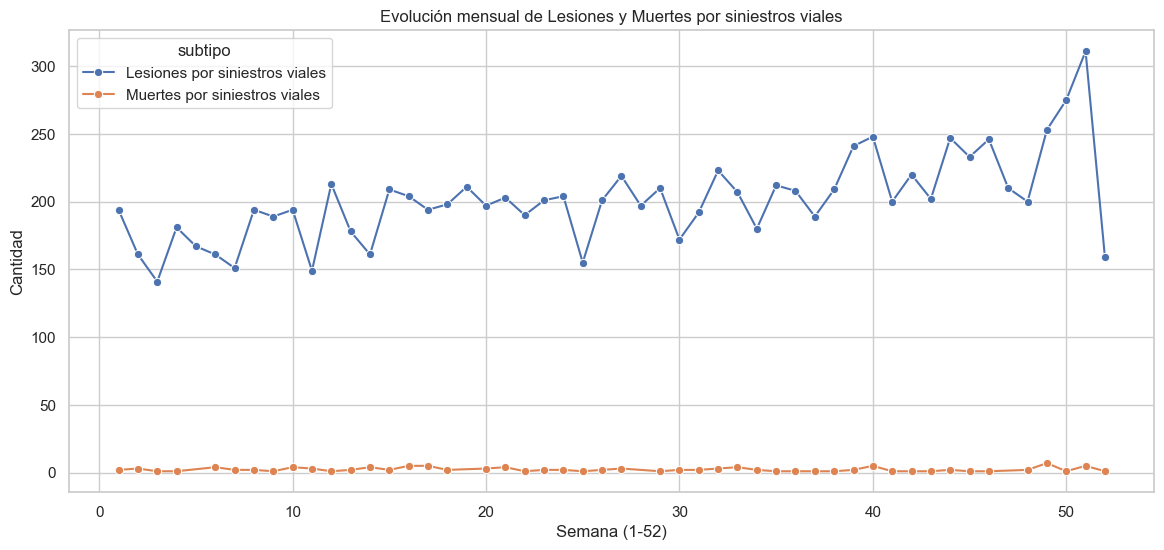

In [103]:
# genero mi dataframe a graficar, delitos relacionasod a vialidad
df_vialidad = df[df['tipo'] == 'Vialidad']

print(df_vialidad.sample(3))
# Ahora que filtré, twngo que elimninar las categorías de 'subtipo' que no entraron en el filtro,
# para que no me las muyestre con 'legend'
df_vialidad['subtipo'] = (
    df_vialidad['subtipo']
    .cat.remove_unused_categories()
)

vialidad_semana = (
    df_vialidad
    .groupby(['semana', 'subtipo'], observed=True)['cantidad']
    .sum()
    .reset_index()
)

vialidad_semana = vialidad_semana.sort_values('semana')

plt.figure(figsize=(14,6))

sns.lineplot(
    data=vialidad_semana,
    x='semana',
    y='cantidad',
    hue='subtipo',
    marker='o',
    legend=True
)

plt.title('Evolución mensual de Lesiones y Muertes por siniestros viales')
plt.xlabel('Semana (1-52)')
plt.ylabel('Cantidad')
#plt.legend(ncol=2, bbox_to_anchor=(0.5, -0.1), loc="upper center")
plt.grid(True)
plt.show()

<Axes: xlabel='semana', ylabel='cantidad'>

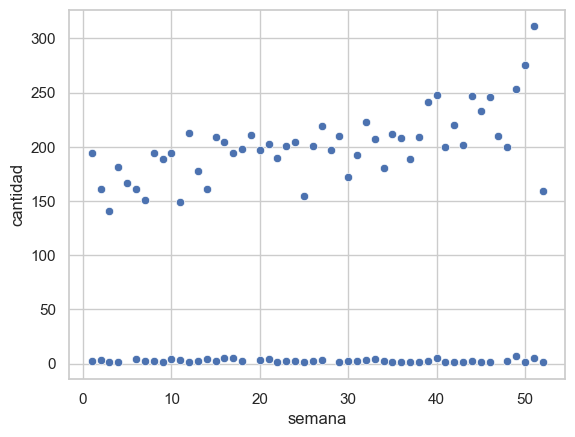

In [98]:

sns.scatterplot(
    data=vialidad_semana,
    y='cantidad',
    x='semana',
    #hue='semana',
    legend=True,
)

In [79]:
vialidad_semana

,semana,subtipo,cantidad
0,1,Lesiones por siniestros viales,194
1,1,Muertes por siniestros viales,2
2,2,Lesiones por siniestros viales,161
3,2,Muertes por siniestros viales,3
4,3,Lesiones por siniestros viales,141
...,...,...,...
95,50,Muertes por siniestros viales,1
96,51,Lesiones por siniestros viales,311
97,51,Muertes por siniestros viales,5
98,52,Lesiones por siniestros viales,159


## `scatterplot` Delitos por barrio vs uso de arma

In [152]:
ndf = (
    #df.groupby(['fecha','barrio','tipo','subtipo'], observed=True)['cantidad']
    df.groupby(['barrio','fecha','tipo','subtipo'], observed=True)['cantidad']
    .sum()
    .reset_index()
)

ndf['barrio']=='Agronomia'

0        False
1        False
2        False
3        False
4        False
         ...  
51356    False
51357    False
51358    False
51359    False
51360    False
Name: barrio, Length: 51361, dtype: bool

<Axes: xlabel='cantidad', ylabel='tipo'>

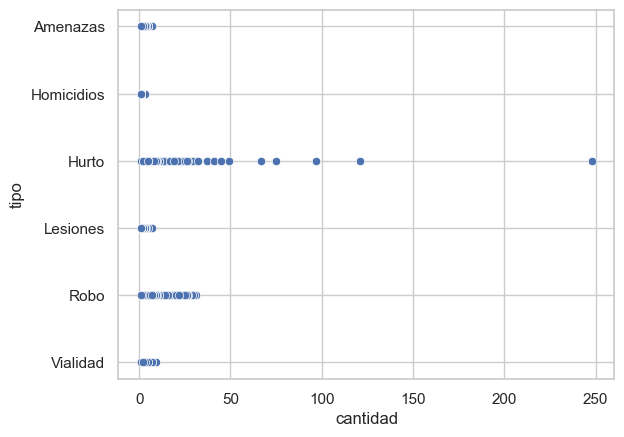

In [146]:
sns.scatterplot(
    data=ndf,
    x='cantidad',
    y='tipo'
)

## `scatterplot` Delitos por semana vs delitos con arma

<Axes: xlabel='delitos_totales', ylabel='delitos_arma'>

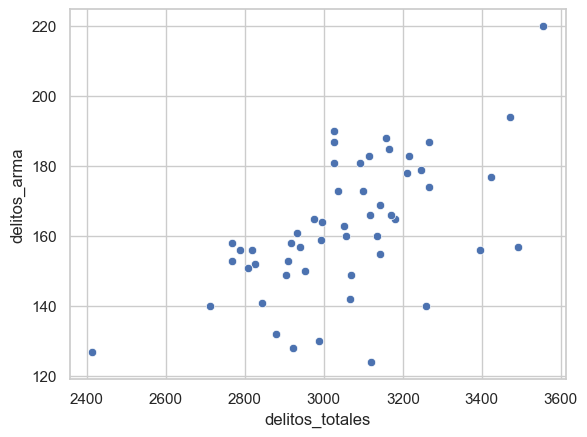

In [81]:
df_semana = (
    df.groupby('semana')
    .agg(
        delitos_totales=('cantidad', 'sum'),
        delitos_arma=('uso_arma', 'sum')
    )
    .reset_index()
)

sns.scatterplot(
    data=df_semana,
    x='delitos_totales',
    y='delitos_arma'
)


## `scatterplot` Scatter geográfico

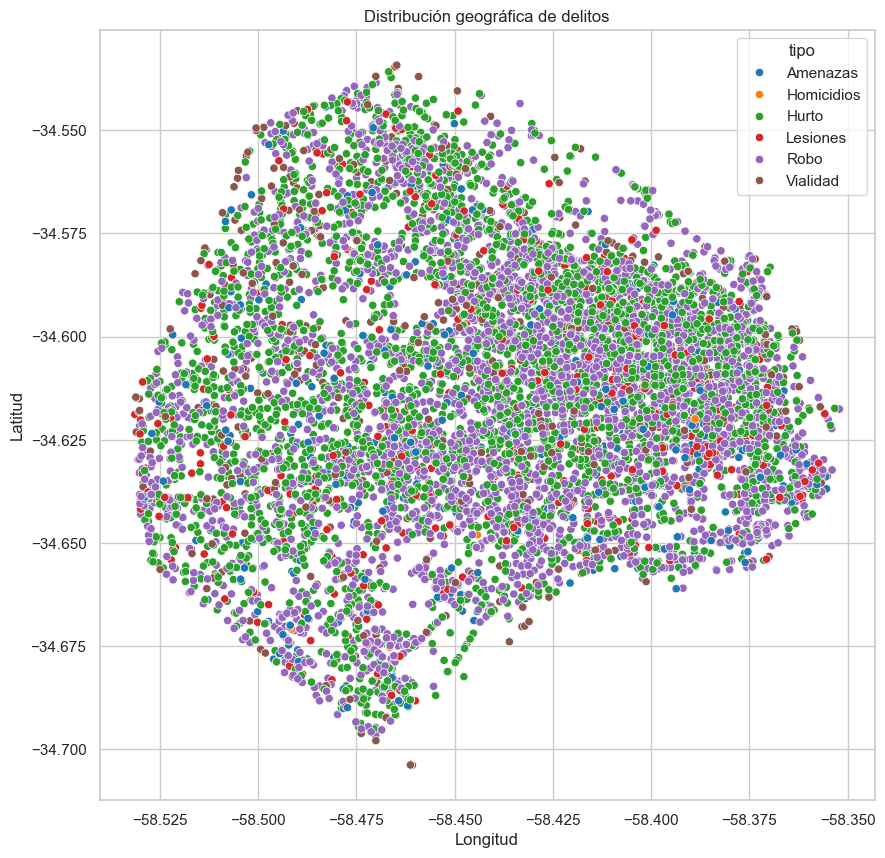

In [158]:
# tengo que limpiar valores que no sirven (nulos o 0)
# en el dataset hay valores mal cargados, como por ejemplo:
#
#  1531137,"2024","ENERO","JUEVES","2024-01-11",8,"Lesiones","Lesiones Dolosas","NO","NO",NULL,NULL,"-3.45946878588094e+17","-58.3799958229065",1
#
# no sólo la latitud está como -3.45946878588094e+17, sino que también faltan otros valores como la comuna y el barrio
# se decide eliminar estos datos del análisis

df_geo = df.dropna(subset=['latitud', 'longitud']) 

df_geo = df_geo[
    (df_geo['latitud'] != 0) &
    (df_geo['longitud'] != 0)
]

plt.figure(figsize=(10,10))

sns.scatterplot(
    data=df_geo.sample(10000),
    x='longitud',
    y='latitud',
    hue='tipo',
    #alpha=1
    palette='tab10'
)

plt.title('Distribución geográfica de delitos')
plt.xlabel('Longitud')
plt.ylabel('Latitud')

plt.show()

### SE PARECE A LA CIUDAD DE BS AS!!!!